<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit4/U4Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unit 4 Project: Hierarchical Models**

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import graphviz as gv
import pymc as pm

In [ ]:
url_sd = 'https://raw.githubusercontent.com/emilchafigoulline/Data-Science/refs/heads/main/Unit4/Dow%20Market%20Data%20-%20DATA%20(1).csv'
sd_data = pd.read_csv(url_sd)
sd_data

,Date,Open,High,Close,Low,Trades,Change,Company
0,10/30/2025,111.940,113.5801,112.620,109.550,36977913,0.607468,DIS
1,10/23/2025,111.030,114.5395,111.680,110.600,36960469,0.585427,DIS
2,10/16/2025,110.390,112.6750,110.670,108.510,39967311,0.253646,DIS
3,10/9/2025,112.690,113.4000,109.190,109.110,34763033,-3.105866,DIS
4,10/2/2025,113.470,116.0590,112.470,110.775,44187657,-0.881290,DIS
...,...,...,...,...,...,...,...,...
670,6/19/2025,143.345,146.2000,142.650,143.850,726691944,-0.484844,NVDA
671,6/12/2025,143.190,145.0000,140.855,141.970,851875991,-1.630700,NVDA
672,6/5/2025,135.490,144.0000,135.400,141.720,976759630,-0.066426,NVDA
673,5/29/2025,134.150,143.4900,132.920,135.130,1200760777,-0.916884,NVDA


# Data
For this project, I used an Alpha Vantage API to compile data for 27 Dow Jones Index companies, creating the data shown above. Included is the open price, high price, close price, and low price, as well as the number of trades. I then used Sheets to calculate the difference between opening and closing price for the Delta value. The delta value is the one we will be working with.

(array([  2.,   2.,   8.,  13.,  22.,  34.,  53.,  93., 136., 183.,  32.,
         32.,  23.,  13.,  15.,   5.,   2.,   0.,   0.,   2.]),
 array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]),
 <BarContainer object of 20 artists>)

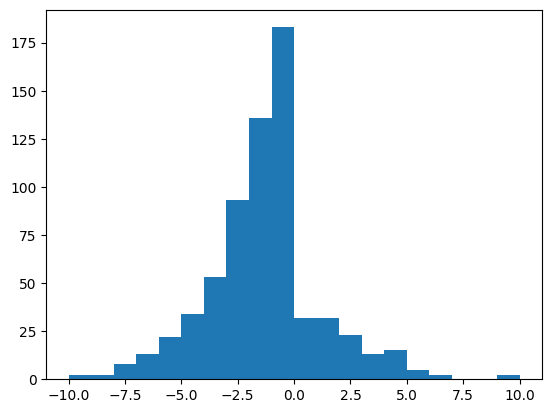

In [ ]:
plt.hist(sd_data['Change'], bins= 20, range = (-10,10))

We can see that this data is slightly skewed to the right, as there are more outlying values to the right.

In [ ]:
tickers_encode = pd.Categorical(sd_data['Company'])
tickers_encode

['DIS', 'DIS', 'DIS', 'DIS', 'DIS', ..., 'NVDA', 'NVDA', 'NVDA', 'NVDA', 'NVDA']
Length: 675
Categories (27, object): ['AAPL', 'AMGN', 'AMZN', 'BA', ..., 'UNH', 'V', 'VZ', 'WMT']

In [ ]:
tickers_idx = tickers_encode.codes
tickers_idx

array([ 8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 18, 18, 18, 18,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 20

In [ ]:
tickers_coords = {"Company": tickers_encode.categories}
tickers_coords
#we classify each company in the index according to their ticker

{'Company': Index(['AAPL', 'AMGN', 'AMZN', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'HD',
        'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA',
        'PG', 'SHW', 'TRV', 'UNH', 'V', 'VZ', 'WMT'],
       dtype='object')}

# Nonhierarchical Models
In this section, I will make two nonhierarchical models of the stocks, which assumes that they are independent of each other. I use the most general priors possible to indicate my unsureness of the tendencies of each stock.

In [ ]:
with pm.Model(coords=tickers_coords) as sd_nh_model:
    #priors
    #dims="Company" means to apply the prior seperately to each stock
    μ = pm.Normal('μ', mu=0, sigma=10,
                  dims="Company")
    σ = pm.HalfNormal('σ', sigma=10,
                      dims="Company")
    nu = pm.Exponential('nu', lam = 0.5, dims = "Company")
    #using lam = 0.5 for a mean of 2

    #The idx variable tells my model which diffs belong to the same stock
    #this will cause my model to generate a posterior for each company
    y = pm.StudentT('y',
                  mu = μ[tickers_idx],
                  sigma = σ[tickers_idx],
                  nu = nu[tickers_idx],
                  observed=sd_data['Change'])

    #sd for stock data, nh for nonheirarchical
    idata_sd_nh = pm.sample()
    #we are using a studentT distribution because this is most accurate for modeling stocks

In [ ]:
pm.sample_posterior_predictive(idata_sd_nh, model = sd_nh_model, extend_inferencedata=True)

(-7.5, 7.5)

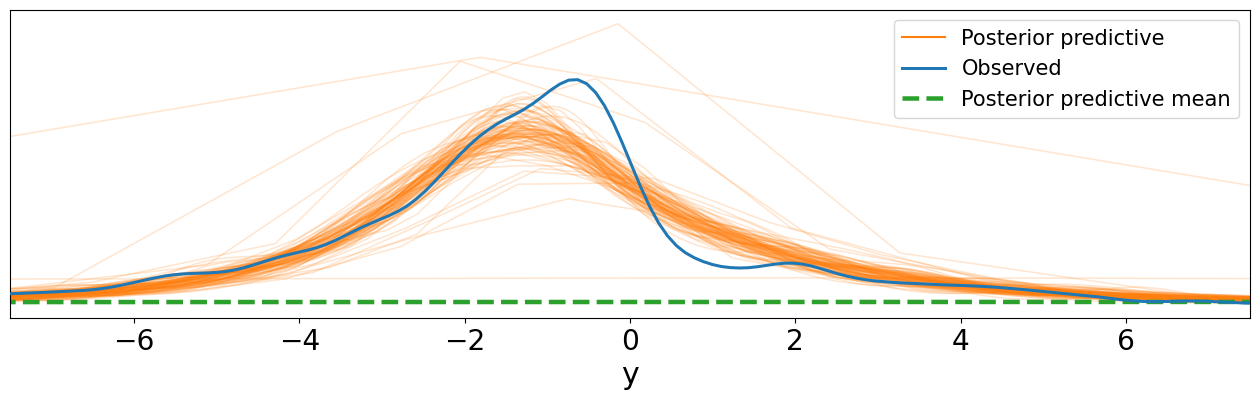

In [ ]:
ax = az.plot_ppc(idata_sd_nh, num_pp_samples=100, figsize=(16, 4), colors=["C1", "C0", "C2"])
ax.set_xlim(-7.5, 7.5)

This model is significantly skewed to the right, which is to be expected for a stock, which typically fits a studentT distribution. As such, we will try another nonhierarchical model with a skewed studentT distribtuion.

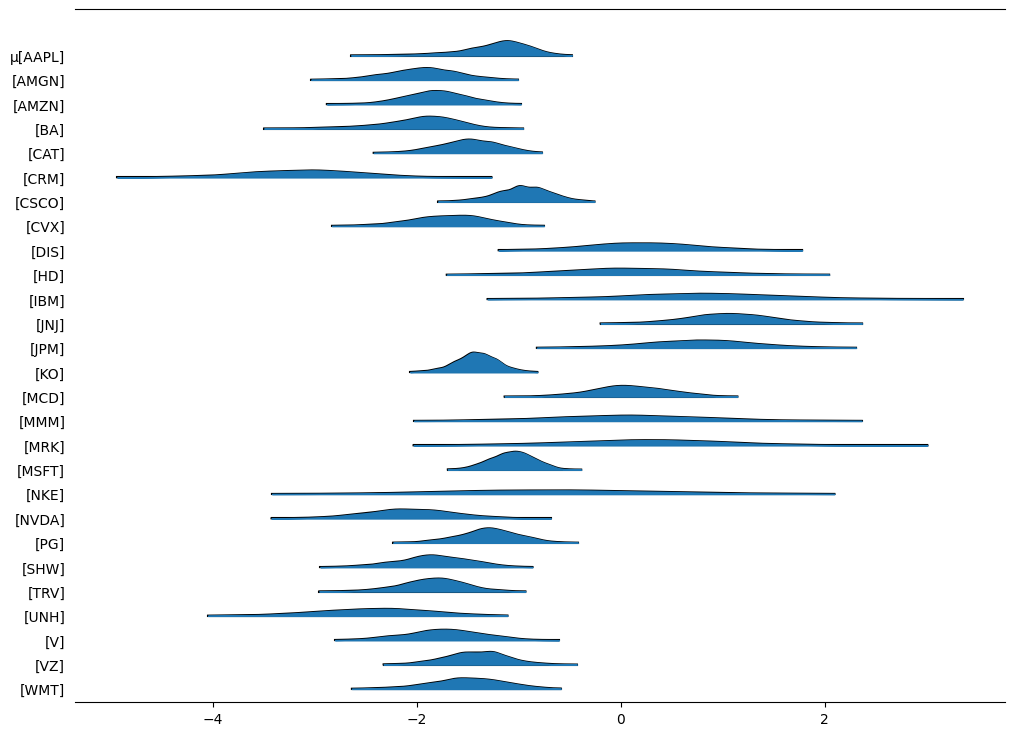

In [ ]:
axes = az.plot_forest(idata_sd_nh, kind="ridgeplot",
                      var_names='μ',
                      combined=True, figsize=(12, 9), hdi_prob=0.997)

In [ ]:
with pm.Model(coords = tickers_coords) as sd_nh2_model:

  # Priors
  μ = pm.Normal('μ', mu = 0, sigma = 10, dims = "Company")
  σ = pm.HalfNormal('σ', sigma = 10, dims = "Company")
  α = pm.Uniform('α', upper = 1, lower = 0.5, dims = "Company")
  β = pm.Uniform('β', upper = 2, lower = 1, dims = "Company")

  # Likelihood
  y = pm.SkewStudentT('y', mu = μ[tickers_idx], sigma = σ[tickers_idx],
                      a = α[tickers_idx], b = β[tickers_idx],
                      observed = sd_data["Change"])

  idata_sd_nh2 = pm.sample()

In [ ]:
pm.sample_posterior_predictive(idata_sd_nh2, model = sd_nh2_model, extend_inferencedata=True)

(-7.5, 7.5)

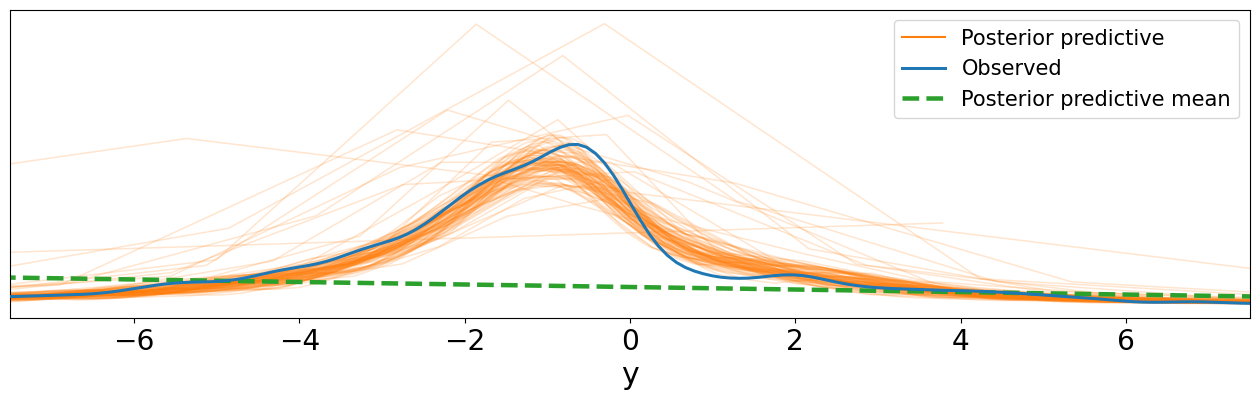

In [ ]:
ax = az.plot_ppc(idata_sd_nh2, num_pp_samples=100, figsize=(16, 4), colors=["C1", "C0", "C2"])
ax.set_xlim(-7.5, 7.5)

As we can see, using a SkewStudentT model instead of a studentT model is much more accurate than the other model. However, the max of the model is still slightly lower than the observed. Let's see if we can get these to match using a hierarchical model.

# Hierarchial Models
Now, in this section, I will model the changes in each stock assuming that they are dependent on each other, related some way or another, since they are all industrial companies in the United States(Dow Jones Index). Again, I use the most general priors and hyperpriors to ensure that my inaccurate prior doesn't overly influence the model.

In [ ]:
with pm.Model(coords=tickers_coords) as sd_h_model:
    # hyperpriors. Notice how there's no dims argument.
    #this means that the hyperprior is shared across all stocks
    μ_mu = pm.Normal('μ_mu', mu = 0, sigma = 10)
    μ_sd = pm.HalfNormal('μ_sd', sigma = 10)
    μ_nu = pm.Exponential('μ_nu', lam = 0.5)

    # priors. There is a different prior for each company,
    #but now the μ priors 'talk' to one another through μ_mu and μ_sd
    μ = pm.StudentT('μ',
                  mu = μ_mu, # I include the hyperprior in my prior
                  sigma = μ_sd, # I include the hyperprior in my prior
                  nu = μ_nu,
                  dims = "Company")

    σ = pm.HalfNormal('σ', sigma = 10,
                      dims = "Company")
    nu = pm.Exponential('nu', lam = 0.5, dims = "Company")

    #likelihood; same as before
    y = pm.StudentT('y',
                  mu = μ[tickers_idx], #I include the prior in my likelihood
                  sigma = σ[tickers_idx], #I include the prior in my likelihood
                  nu = nu[tickers_idx],
                  observed = sd_data['Change'])

    #sd for stock data, h for hierarchical
    idata_sd_h = pm.sample()

In [ ]:
pm.sample_posterior_predictive(idata_sd_h, model = sd_h_model, extend_inferencedata=True)

(-5.0, 5.0)

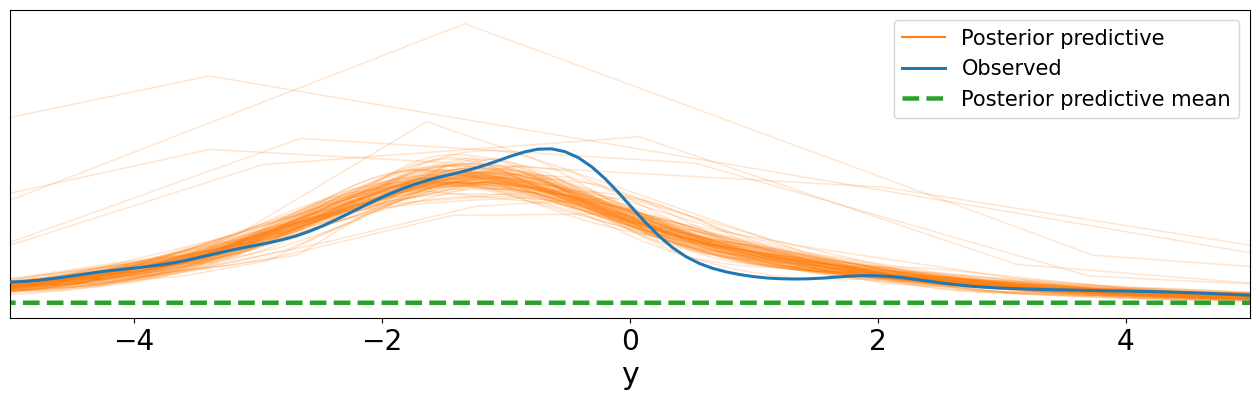

In [ ]:
ax = az.plot_ppc(idata_sd_h, num_pp_samples=100, figsize=(16, 4), colors=["C1", "C0", "C2"])
ax.set_xlim(-5, 5)

Again, this model is significantly skewed to the right so we will use a SkewStudentT distribution. This will hopefully shift our model to be correct.

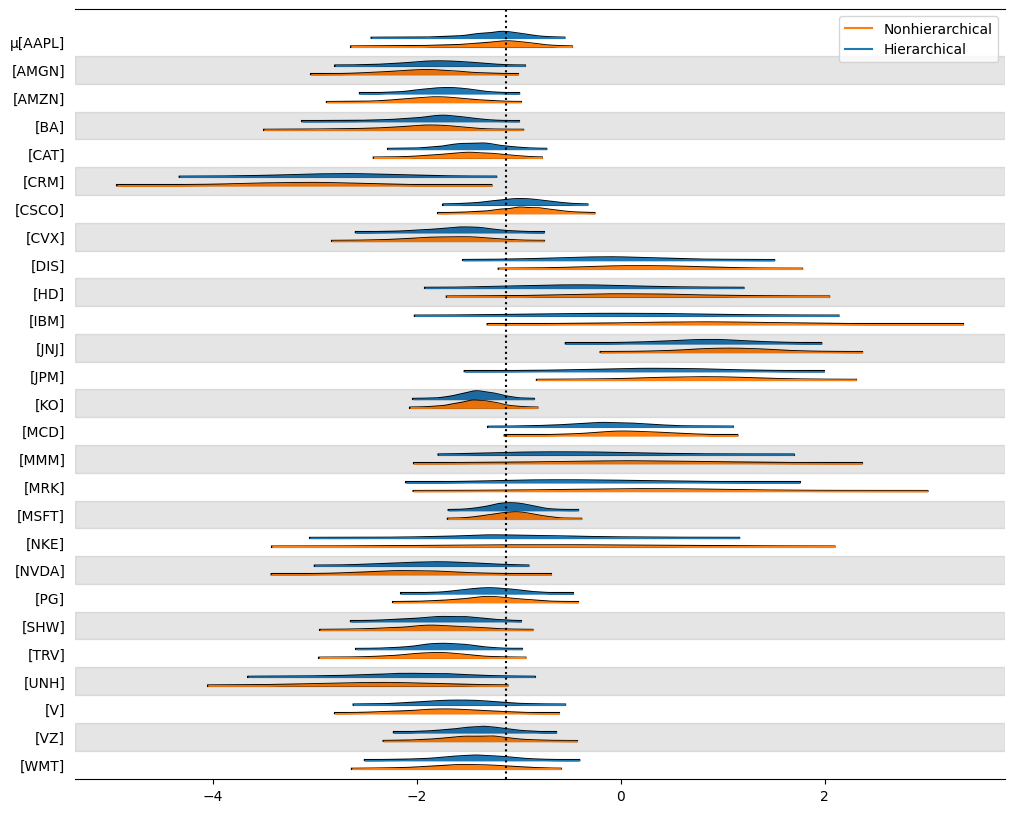

In [ ]:

axes = az.plot_forest([idata_sd_h, idata_sd_nh], kind="ridgeplot",
                      model_names=['Hierarchical', 'Nonhierarchical'],
                      var_names='μ', combined=True, figsize=(12, 10),hdi_prob=0.997)

y_lims = axes[0].get_ylim()
axes[0].vlines(idata_sd_h.posterior['μ'].mean(), *y_lims, color="k", ls=":");

We can see the effects of the hierarchical model through the shrinkage of the ditribution, with the variance decreased through creating hyperpriors.

<xarray.Dataset> Size: 1kB
Dimensions:  (Company: 27)
Coordinates:
  * Company  (Company) <U4 432B 'AAPL' 'AMGN' 'AMZN' 'BA' ... 'V' 'VZ' 'WMT'
Data variables:
    nu       (Company) float64 216B 1.0 0.9996 0.9999 1.001 ... 1.002 1.0 1.001
    μ        (Company) float64 216B 1.002 1.001 0.9997 ... 1.001 1.003 1.002
    μ_mu     float64 8B 1.0
    μ_nu     float64 8B 1.0
    μ_sd     float64 8B 1.002
    σ        (Company) float64 216B 1.002 1.005 0.9996 ... 1.001 1.0 0.9995

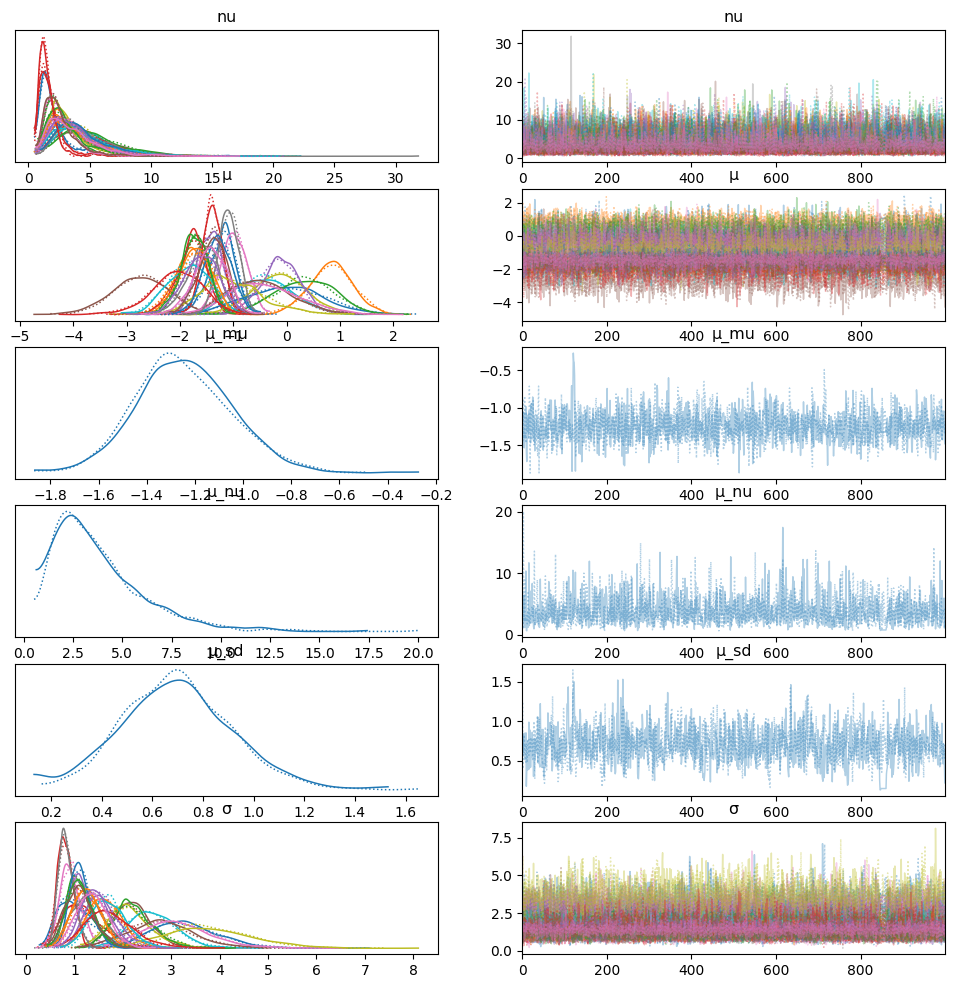

In [ ]:

az.plot_trace(idata_sd_h)
az.rhat(idata_sd_h)

There is significant variation in the mean curves, as we can see some distributions are not centered around 0.

In [ ]:
with pm.Model(coords = tickers_coords) as sd_h2_model:

  # Hyperpriors
  μ_mu = pm.Normal('μ_mu', mu = 0, sigma = 10)
  σ_mu = pm.HalfNormal('σ_mu', sigma = 10)
  α_mu = pm.Uniform('α_mu', upper = 1, lower = 0.5)
  β_mu = pm.Uniform('β_mu', upper = 2, lower = 1)

  σ_sigma = pm.HalfNormal('σ_sigma', sigma = 10)

  # Priors
  μ = pm.SkewStudentT('μ', mu = μ_mu, sigma = σ_mu, a = α_mu, b = β_mu, dims = "Company")
  σ = pm.HalfNormal('σ', sigma = σ_sigma, dims = "Company")


  # Likelihood
  y = pm.SkewStudentT('y',
                      mu = μ[tickers_idx],
                      sigma = σ[tickers_idx],
                      a = α_mu,
                      b = β_mu,
                      observed = sd_data["Change"])

  idata_sd_h2 = pm.sample()

In [ ]:
pm.sample_posterior_predictive(idata_sd_h2, model = sd_h2_model, extend_inferencedata=True)

(-10.0, 10.0)

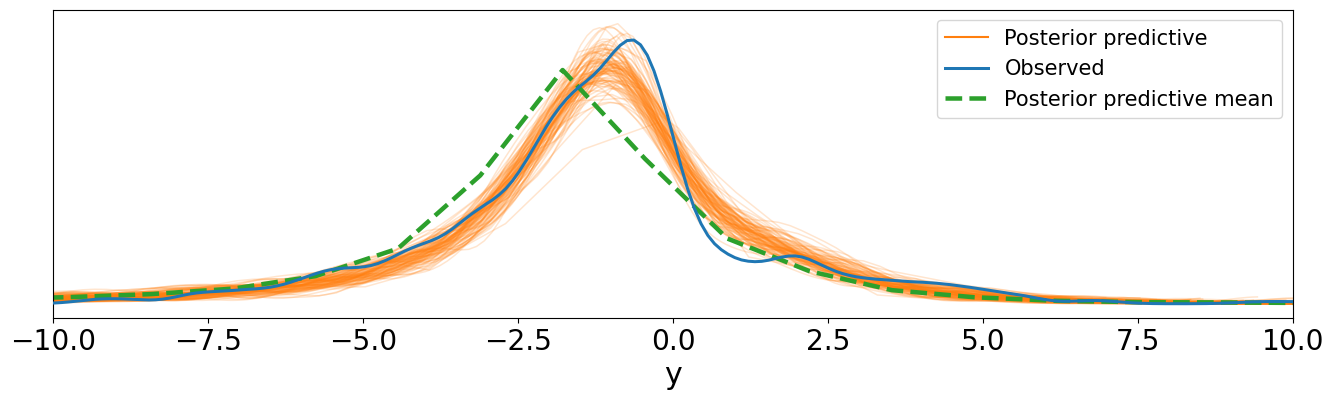

In [ ]:
ax = az.plot_ppc(idata_sd_h2, num_pp_samples=100, figsize=(16, 4), colors=["C1", "C0", "C2"])
ax.set_xlim(-10, 10)

While there is still some variation between the observed and the posterior predictive, this is a much better model.

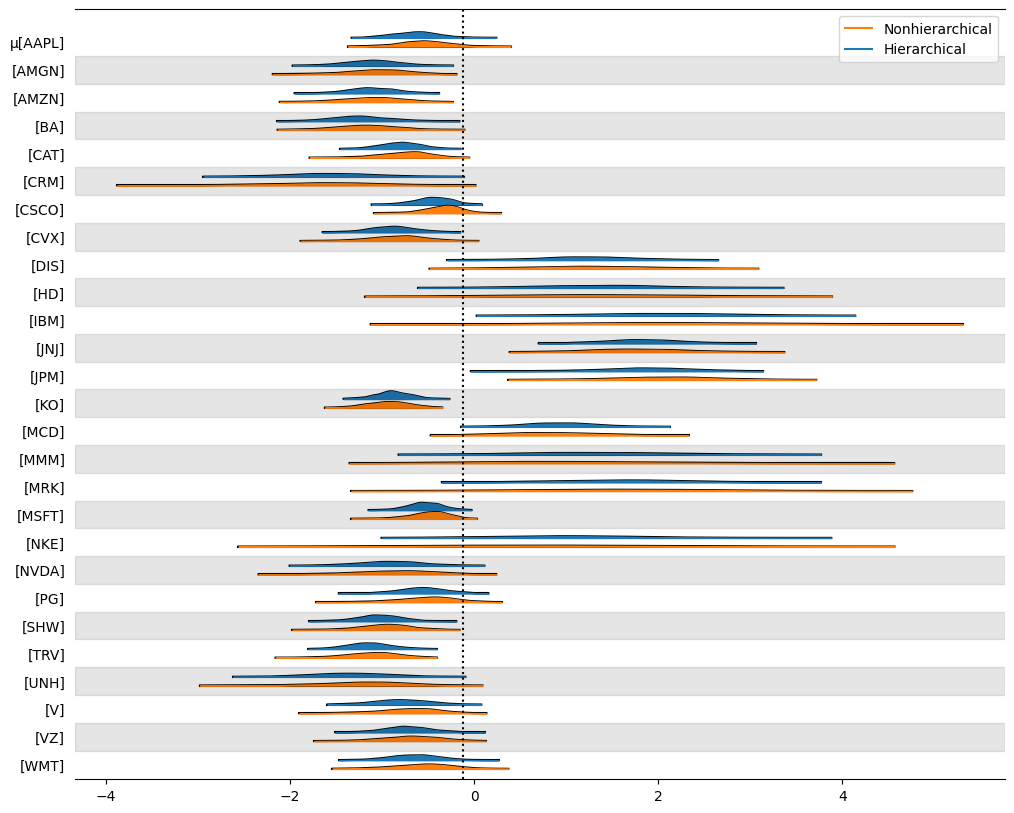

In [ ]:
axes = az.plot_forest([idata_sd_h2, idata_sd_nh2], kind="ridgeplot",
                      model_names=['Hierarchical', 'Nonhierarchical'],
                      var_names='μ', combined=True, figsize=(12, 10),hdi_prob=0.997)

#plots overall mean of the hierarchical model
y_lims = axes[0].get_ylim()
axes[0].vlines(idata_sd_h2.posterior['μ'].mean(), *y_lims, color="k", ls=":");

<xarray.Dataset> Size: 904B
Dimensions:  (Company: 27)
Coordinates:
  * Company  (Company) <U4 432B 'AAPL' 'AMGN' 'AMZN' 'BA' ... 'V' 'VZ' 'WMT'
Data variables:
    α_mu     float64 8B 1.004
    β_mu     float64 8B 1.004
    μ        (Company) float64 216B 1.002 1.001 1.0 1.0 ... 1.004 1.001 1.0
    μ_mu     float64 8B 1.005
    σ        (Company) float64 216B 1.001 1.001 0.9995 ... 1.003 1.005 1.0
    σ_mu     float64 8B 1.003
    σ_sigma  float64 8B 1.002

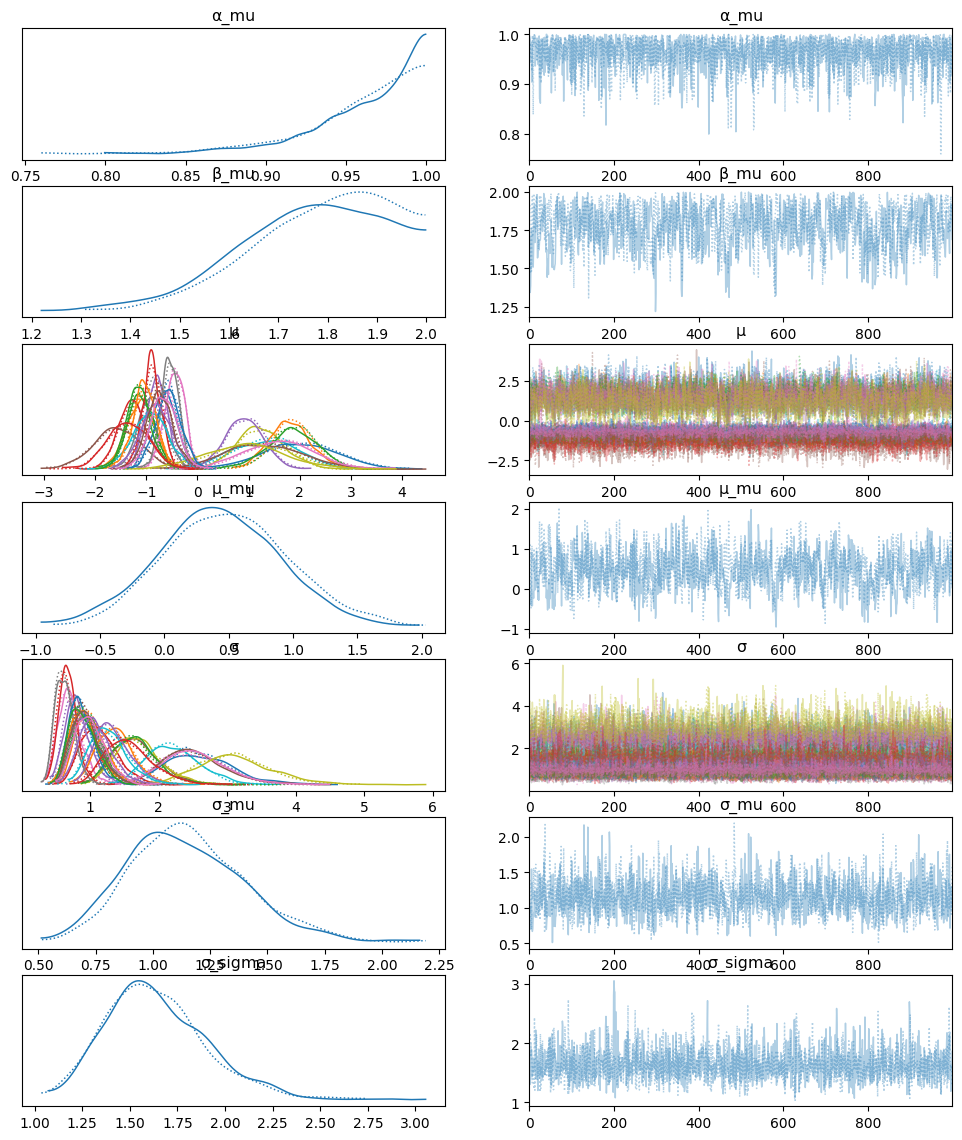

In [ ]:
az.plot_trace(idata_sd_h2)
az.rhat(idata_sd_h2)

We can again see some variation in the distribution, indicating some of the comapanies aren't correllated with the others, but for the most part the curves appear similar.

And finally, based on the comparison of hierarchical and nonhierarchical models, we can conclude that there is a correlation between the individual companies of the Dow Jones stock index, seen through reduced variance of each hierarchical curve compared to its nonhierarchical counterpart.